In [23]:
# Importing libraries and fetching data

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

data = yf.download("^NSEI", period="3y", interval= "1d")
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.dropna(inplace=True)

data['EMA50'] = data['Close'].ewm(span=50, adjust=False).mean()


[*********************100%***********************]  1 of 1 completed


In [24]:
# Backtesting with Proper Risk-Reward

capital = 100000
risk_percent = 0.01
reward_ratio = 2

in_position = False
trades = []
buy_points = []
sell_points = []

for i in range(1, len(data)):
    if not in_position and data['Close'].iloc[i] > data['EMA50'].iloc[i]:
        entry_price = data['Close'].iloc[i]

        stop_loss = entry_price * (1 - risk_percent)
        risk_per_unit = entry_price - stop_loss

        position_size = (capital * risk_percent) / risk_per_unit

        target = entry_price + ( risk_per_unit * reward_ratio)

        in_position = True
        buy_points.append((data.index[i], entry_price))

    elif in_position:
        price = data['Close'].iloc[i]

        # stop loss hit
        if price <= stop_loss:
            loss = (stop_loss - entry_price) * position_size
            capital += loss
            trades.append(loss)
            sell_points.append((data.index[i], price))
            in_position = False

        # target hit
        elif price >= target:
            profit = (target - entry_price) * position_size
            capital += profit
            trades.append(profit)
            sell_points.append((data.index[i], price))
            in_position = False        



In [25]:
# Performance Metrics

total_trades = len(trades)
wins = [t for t in trades if t > 0]

win_rate = (len(wins) / total_trades) * 100 if total_trades > 0 else 0
total_profit = sum(trades)

# Max Drawdown Calculation
equity_curve = np.cumsum(trades)
rolling_max = np.maximum.accumulate(equity_curve)
drawdown = equity_curve - rolling_max
max_drawdown = drawdown.min()

print("Total Trades:", total_trades)
print("Win Rate: {:.2f}%".format(win_rate))
print("Max Drawdown:", max_drawdown)
print("Total Profit/Loss:", total_profit)


Total Trades: 63
Win Rate: 49.21%
Max Drawdown: -5223.014861546646
Total Profit/Loss: 33946.55603800873


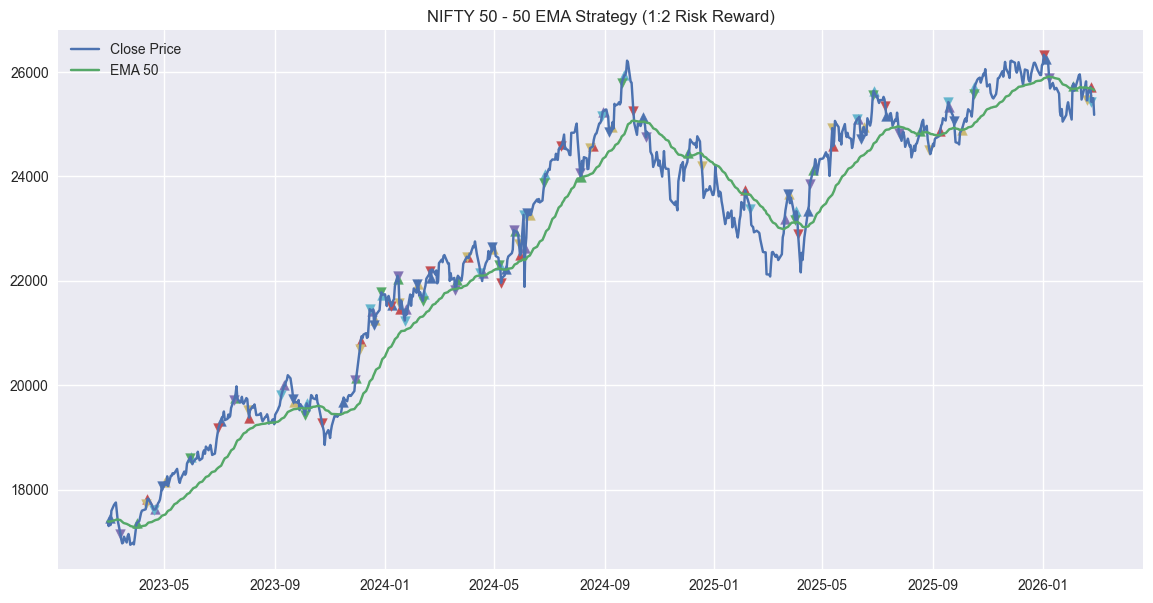

In [26]:
# Data Visualization

plt.figure(figsize=(14,7))
plt.plot(data['Close'], label= 'Close Price')
plt.plot(data['EMA50'], label= 'EMA 50')

for point in buy_points:
    plt.scatter(point[0],point[1], marker='^')

for point in sell_points:
    plt.scatter(point[0],point[1], marker='v')    

plt.legend()
plt.title("NIFTY 50 - 50 EMA Strategy (1:2 Risk Reward)")    
plt.show()

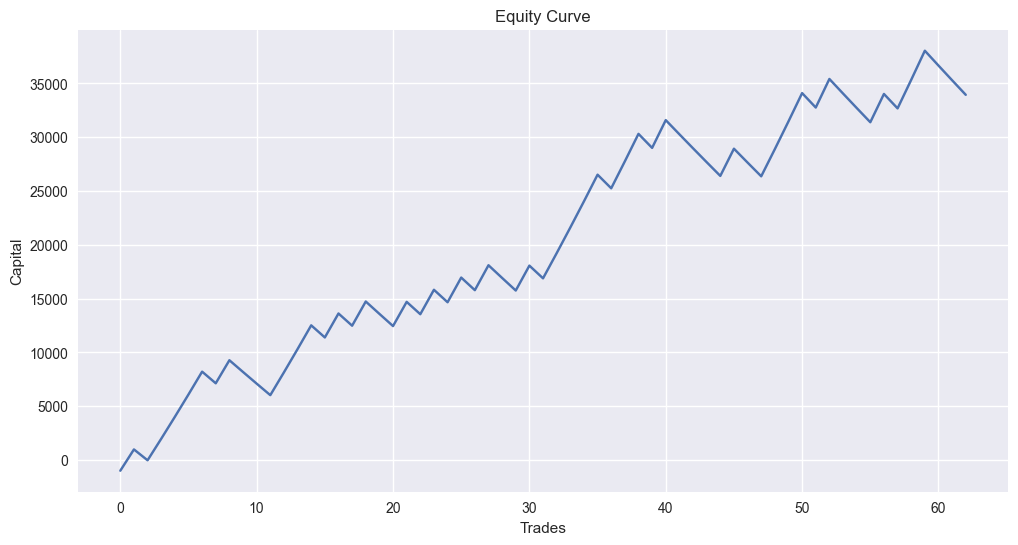

In [27]:
# Equity Curve Visualization

plt.figure(figsize=(12,6))
plt.plot(equity_curve)
plt.title("Equity Curve")
plt.xlabel("Trades")
plt.ylabel("Capital")
plt.show()